In [1]:
from google.colab import files
uploaded = files.upload()

Saving student.zip to student.zip


In [2]:
import zipfile
import os

zip_file_name = 'student.zip'

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('student_data')

print("Files extracted successfully!")
print(os.listdir('student_data'))

Files extracted successfully!
['student-mat.csv', 'student-merge.R', 'student.txt', 'student-por.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
file_path = 'student_data/student-mat.csv'

df = pd.read_csv(file_path, sep=';')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
print(df.shape)

(395, 33)


In [7]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


In [9]:
df = df.drop_duplicates()

print(df.shape)

(395, 33)


In [10]:
average_grade = df['G3'].mean()

print("Average Final Grade:", average_grade)

Average Final Grade: 10.415189873417722


In [11]:
students_above_15 = df[df['G3'] > 15]

print("Students scoring above 15:")
print(students_above_15.shape[0])

Students scoring above 15:
40


In [12]:
correlation = df['studytime'].corr(df['G3'])

print("Correlation:", correlation)

Correlation: 0.09781968965319626


In [13]:
gender_performance = df.groupby('sex')['G3'].mean()

print(gender_performance)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


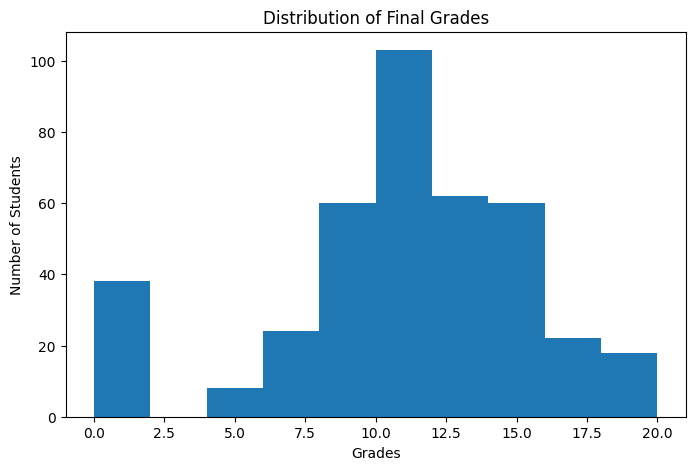

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df['G3'], bins=10)

plt.title('Distribution of Final Grades')
plt.xlabel('Grades')
plt.ylabel('Number of Students')

plt.show()

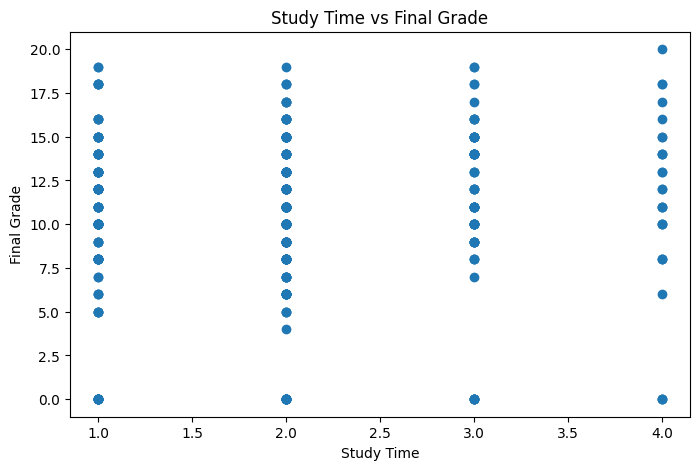

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(df['studytime'], df['G3'])

plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')

plt.show()

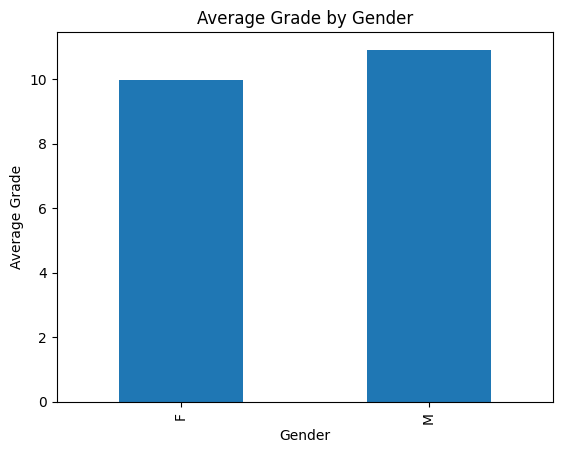

In [16]:
gender_performance.plot(kind='bar')

plt.title('Average Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Grade')

plt.show()

In [17]:
print("===== FINAL CONCLUSION =====")

print("Average Grade:", round(average_grade, 2))

print("Students Above 15:", students_above_15.shape[0])

print("Correlation:", round(correlation, 2))

if gender_performance['F'] > gender_performance['M']:
    print("Female students performed better on average.")
else:
    print("Male students performed better on average.")

===== FINAL CONCLUSION =====
Average Grade: 10.42
Students Above 15: 40
Correlation: 0.1
Male students performed better on average.
